# Topo-Align: Advanced Topological Alignment Showcase

Welcome to the comprehensive showcase for **Topo-Align**, a library for multi-objective alignment using topological fixed-point search (Sperner's Lemma).

This notebook demonstrates:
1.  **3-Objective Visualizations**: Heatmaps and Simplex Paths.
2.  **N-Dimensional Scaling**: Solving high-dimensional trade-offs.
3.  **Surrogate Acceleration**: Active learning to minimize expensive oracle calls.
4.  **Frustration Score**: Diagnostic tool for conflicting objectives.
5.  **RLHF Steering**: Practical application for LLM alignment.

## 0. Setup and Imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure project root is in path
if "equilib" not in sys.modules:
    sys.path.insert(0, os.path.abspath("."))

from equilib.topo_align import TopoAlignSolver
from equilib.ndim_topo_align import NDimTopoAlignSolver
from equilib.surrogate_topo_align import NDimSurrogateTopoAlignSolver
from equilib.analytics import calculate_frustration_score
from equilib.plotting import plot_sperner_path, plot_simplex_heatmap
from equilib.rlhf_steering_demo import RLHFSteeringSolver, RLHFSteeringOracle

%matplotlib inline
print("[OK] Topo-Align Library Loaded Successfully")

[OK] Topo-Align Library Loaded Successfully


## 1. 3-Objective Alignment with Visualizations

For 3 objectives, the search space is a 2D triangle (Simplex). We can visualize the 'Labeling Landscape' and the path the solver takes to find the equilibrium.


[WALK] Starting Topo-Align Walk (Grid Size 25)...
[START] Scanning Boundary y=0 for {0, 2} door...
[DOOR] Found Entry Door at x=12: Labels 2-0
[STEP 1] Centroid [0.49 0.01 0.49] | Labels [np.int64(0), np.int64(1), np.int64(2)]

[SUCCESS] FIXED POINT FOUND!

[SUCCESS] Equilibrium Found at: [0.493 0.013 0.493]
Targets were: [0.33 0.33 0.34]


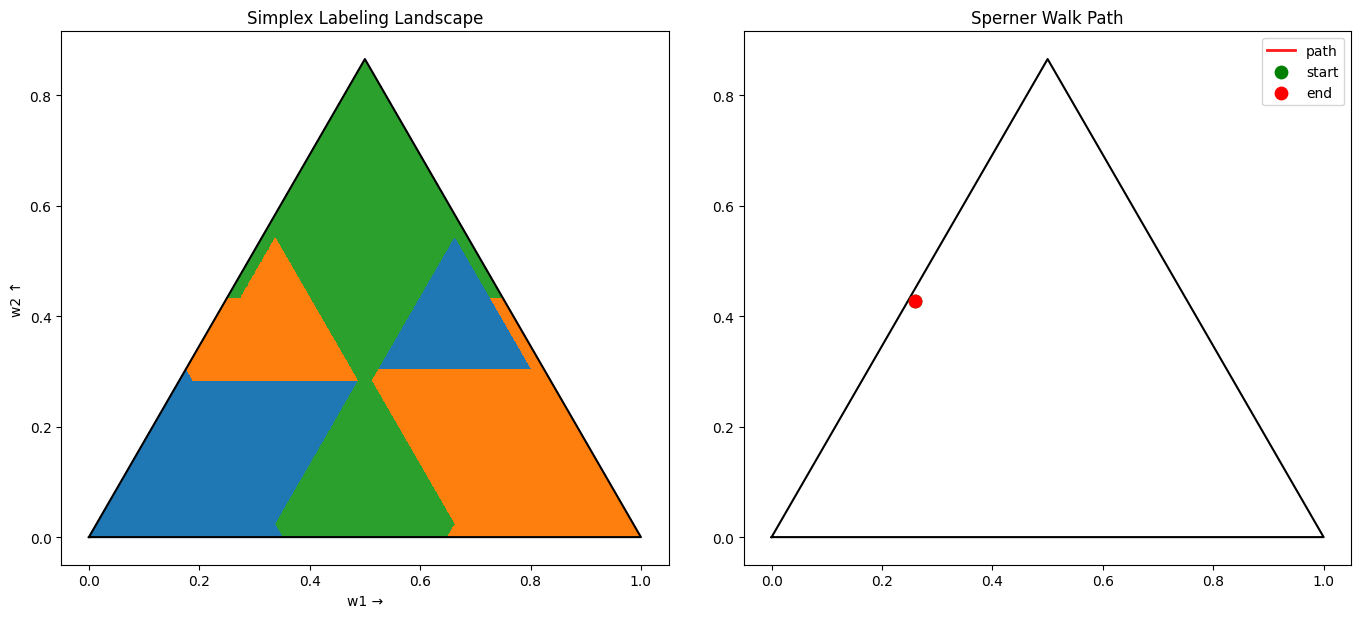

In [2]:
# Initialize a 3-objective solver with a grid resolution of 25
solver_3d = TopoAlignSolver(subdivision=25)

# 1. Plot the Simplex Heatmap (The 'Regions of Influence' for each objective)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def oracle_fn(w):
    # Standard solver uses argmax of squared distance from targets
    losses = (w - solver_3d.targets)**2
    # Enforce boundary conditions
    for i in range(3):
        if w[i] == 0: losses[i] = -1.0
    return np.argmax(losses)

plot_simplex_heatmap(oracle_fn, n_grid=40, ax=ax1, title="Simplex Labeling Landscape")

# 2. Run the Walk and Plot the Path
result_tri, path_triangles = solver_3d.walk()

if result_tri:
    # Convert triangle centroids to weights for plotting
    path_weights = []
    for tri in path_triangles:
        cx = sum(p[0] for p in tri)/3
        cy = sum(p[1] for p in tri)/3
        path_weights.append(solver_3d.weights_from_coords(cx, cy))
    
    plot_sperner_path(path_weights, ax=ax2, title="Sperner Walk Path")
    
    cx = sum(p[0] for p in result_tri)/3
    cy = sum(p[1] for p in result_tri)/3
    best_w = solver_3d.weights_from_coords(cx, cy)
    print(f"\n[SUCCESS] Equilibrium Found at: {np.round(best_w, 3)}")
    print(f"Targets were: {solver_3d.targets}")

plt.tight_layout()
plt.show()

## 2. N-Dimensional Solver (Generalized Simplex)

When we have >3 objectives, we can no longer visualize it as a simple triangle. The `NDimTopoAlignSolver` uses a generalized Freudenthal triangulation and a 'Lifting' procedure (building the solution dimension-by-dimension).

In [3]:
n_objs = 5
print(f"--- Solving for {n_objs} Objectives ---")
ndim_solver = NDimTopoAlignSolver(n_objs=n_objs, subdivision=20)

# The solver uses internal targets if none provided
result = ndim_solver.solve()

if result is not None:
    print(f"\n[SUCCESS] Final weights for {n_objs}D simplex:")
    for i, w in enumerate(result):
        print(f"  Objective {i}: {w:.4f}")
    print(f"Sum check: {result.sum():.4f}")
else:
    print("\n[FAIL] Solver did not converge.")

--- Solving for 5 Objectives ---
[SUCCESS] Final 5-Objective Fixed Point Found!
[RESULT] Weights: [0.96 0.01 0.01 0.01 0.01]
[METRIC] Topological Frustration Score: 1.00

[SUCCESS] Final weights for 5D simplex:
  Objective 0: 0.9600
  Objective 1: 0.0100
  Objective 2: 0.0100
  Objective 3: 0.0100
  Objective 4: 0.0100
Sum check: 1.0000


## 3. Surrogate-Based Acceleration

In real scenarios (like RLHF), evaluating the 'Oracle' is expensive (e.g., training a model or asking a human). The Surrogate Solver uses **Active Learning** (with a KNN classifier) to predict labels and only calls the real oracle when necessary.

In [4]:
print("--- Surrogate vs. Standard Comparison ---")

# 1. Standard N-Dim Solver (Baseline)
solver_baseline = NDimTopoAlignSolver(n_objs=3, subdivision=30)
solver_baseline.solve()
standard_calls = len(solver_baseline.cache)
print(f"Standard Solver: {standard_calls} oracle calls")

# 2. Surrogate N-Dim Solver
# n_init_samples: Number of initial points to bootstrap the surrogate
solver_surrogate = NDimSurrogateTopoAlignSolver(n_objs=3, subdivision=30, n_init_samples=15)
solver_surrogate.solve_with_surrogate()
surrogate_calls = solver_surrogate.real_queries

print(f"Surrogate Solver: {surrogate_calls} real oracle calls")
print(f"Efficiency gain: {standard_calls / surrogate_calls:.1f}x reduction in expensive calls")

--- Surrogate vs. Standard Comparison ---
[SUCCESS] Final 3-Objective Fixed Point Found!
[RESULT] Weights: [0.978 0.011 0.011]
[METRIC] Topological Frustration Score: 1.00
Standard Solver: 3 oracle calls
[INIT] N-Dim Surrogate: n_objs=3, n_init=15

[SURROGATE] Iter 1/15 (real queries so far: 18)...
[SUCCESS] Final 3-Objective Fixed Point Found!
[RESULT] Weights: [-0.011  0.989  0.022]
[METRIC] Topological Frustration Score: 1.00
[RE-ALIGN] Surrogate disagreed; retraining and retrying.

[SURROGATE] Iter 2/15 (real queries so far: 21)...
[SUCCESS] Final 3-Objective Fixed Point Found!
[RESULT] Weights: [-0.011  0.822  0.189]
[METRIC] Topological Frustration Score: 1.01
[RE-ALIGN] Surrogate disagreed; retraining and retrying.

[SURROGATE] Iter 3/15 (real queries so far: 24)...
[SUCCESS] Final 3-Objective Fixed Point Found!
[RESULT] Weights: [-0.011  0.755  0.256]
[METRIC] Topological Frustration Score: 1.01
[RE-ALIGN] Surrogate disagreed; retraining and retrying.

[SURROGATE] Iter 4/15 (re

## 4. Analytics: Frustration Score

The **Frustration Score** measures the 'winding' of the search path. A score near 1.0 indicates a smooth alignment. A high score (>3.0) suggests that the objectives are in deep conflict (a 'frustrated' landscape).

In [5]:
# Example 1: Stable Path
stable_path = [np.array([0.8, 0.1, 0.1]), np.array([0.6, 0.2, 0.2]), np.array([0.33, 0.33, 0.33])]
score_stable = calculate_frustration_score(stable_path)

# Example 2: Frustrated/Conflicting Path (long path, small displacement)
frustrated_path = [
    np.array([0.8, 0.1, 0.1]), 
    np.array([0.1, 0.8, 0.1]), 
    np.array([0.1, 0.1, 0.8]), 
    np.array([0.33, 0.33, 0.33])
]
score_frustrated = calculate_frustration_score(frustrated_path)

print(f"Stable Path Frustration:    {score_stable:.2f} (Clean alignment)")
print(f"Frustrated Path Frustration: {score_frustrated:.2f} (High conflict detected!)")

Stable Path Frustration:    1.00 (Clean alignment)
Frustrated Path Frustration: 4.46 (High conflict detected!)


## 5. RLHF Steering Demo

This simulates finding the optimal mixing weights for a Reward Model or MoE (Mixture of Experts) to achieve specific performance targets on metrics like **Safety**, **Helpfulness**, and **Verbosity**.

In [6]:
# Target: High Safety (0.8), High Helpfulness (0.7), but Modest Verbosity (0.4)
targets = [0.7, 0.8, 0.4]
rlhf_solver = RLHFSteeringSolver(subdivision=30, targets=targets)

result_tri, _ = rlhf_solver.walk()

if result_tri:
    cx = sum(p[0] for p in result_tri)/3
    cy = sum(p[1] for p in result_tri)/3
    best_w = rlhf_solver.weights_from_coords(cx, cy)
    
    print("\n" + "="*40)
    print(" [RLHF] OPTIMIZATION RESULT")
    print("="*40)
    print(f"Optimal Mixing Weights (H, S, V): {np.round(best_w, 3)}")
    
    # Validate against the simulated model
    oracle = RLHFSteeringOracle()
    final_metrics = oracle.evaluate_model(*best_w)
    print("-" * 40)
    print(f"Target Metrics:   {targets}")
    print(f"Achieved Metrics: {np.round(final_metrics, 3)}")
    print("="*40)

[RLHF] Steering Objectives: Helpfulness=0.7, Safety=0.8, Verbosity=0.4

[WALK] Starting Topo-Align Walk (Grid Size 30)...
[START] Scanning Boundary y=0 for {0, 2} door...
[DOOR] Found Entry Door at x=0: Labels 2-0
[STEP 1] Centroid [0.01 0.01 0.98] | Labels [np.int64(0), np.int64(1), np.int64(2)]

[SUCCESS] FIXED POINT FOUND!

 [RLHF] OPTIMIZATION RESULT
Optimal Mixing Weights (H, S, V): [0.011 0.011 0.978]
----------------------------------------
Target Metrics:   [0.7, 0.8, 0.4]
Achieved Metrics: [0.301 0.109 0.589]


## 6. Human-in-the-Loop Interaction

For practical use, you can replace the automated oracle with human feedback. The library provides a `SpernerTrainer.train_generator` that yields model weights and waits for a human 'verdict' (which objective is farthest from the goal).

### Interactive UI
To use the full Human UI, run the following in your terminal:
```bash
uv run streamlit run equilib/human_ui.py
```

### Programmatic Human Loop (Simulated below)

In [7]:
from equilib.sperner_trainer import SpernerTrainer

trainer = SpernerTrainer("mock-llm", ["Helpfulness", "Safety", "Brevity"], [])
gen = trainer.train_generator(grid_size=6)

print("Starting interactive human loop (Mocked with 5 steps)...")
try:
    # Get first proposal
    weights, status = next(gen)
    for i in range(5):
        print(f"Step {i+1}: Proposal {np.round(weights, 3)}")
        # In a real UI, the user would click a button here.
        # Simulated feedback: objective 1 (Safety) is most dissatisfied.
        verdict = 1 
        weights, status = gen.send(verdict)
except StopIteration as e:
    print(f"Alignment converged to: {e.value}")

[INIT] Running in MOCK MODE (Simulation).
Starting interactive human loop (Mocked with 5 steps)...

[SPERNER-INTERACTIVE] Starting Generator for 3 Adapters...
Step 1: Proposal [1. 0. 0.]
Step 2: Proposal [0.833 0.167 0.   ]
Step 3: Proposal [0.833 0.    0.167]
Alignment converged to: None
